# World Happinies - EDA Project

Unlocking Global Happiness: A 10-Year Visual Exploration (2015–2024)

What truly drives human well-being across the globe? Is it economic prosperity, social support, or personal freedom? Drawing on ten years of data (2015–2024) from the United Nations Sustainable Development Solutions Network (SDSN) World Happiness Report, this project explores the multi-dimensional factors that shape global happiness. Through dynamic data visualizations, interactive charts, and trend analyses, we unpack how social, economic, and emotional indicators have evolved across regions over a transformative decade.

<img src='https://aarp.widen.net/content/voxxutjir1/jpeg/1140-world-happiness.jpg?crop=true&anchor=0,0&q=80&color=ffffffff&u=ovnylx&w=1140&h=655' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import glob
import os

%matplotlib inline
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## EDA 

In [2]:
df = pd.read_csv('world_happiness_combined.csv', sep=';', decimal=',')

In [3]:
df.head()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [4]:
df.tail()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
1497,78,Venezuela,Latin America and Caribbean,5.6067,0.00000,0.81740,70,0.59990,0.47969,0.14982,2024
1498,54,Vietnam,Southeast Asia,6.0430,6.21579,0.78378,71,0.97594,0.23369,0.27818,2024
1499,130,Yemen,Middle East and North Africa,3.5610,3.13606,0.79273,64,0.41974,0.19988,0.19678,2024
1500,131,Zambia,Sub-Saharan Africa,3.5024,4.19978,0.50041,63,0.84216,0.41825,0.19012,2024
1501,135,Zimbabwe,Sub-Saharan Africa,3.3411,3.49606,0.52587,62,0.56401,0.23983,0.22708,2024


In [5]:
df.shape

(1502, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ranking                       1502 non-null   int64  
 1   Country                       1502 non-null   object 
 2   Regional indicator            1499 non-null   object 
 3   Happiness score               1502 non-null   float64
 4   GDP per capita                1502 non-null   float64
 5   Social support                1502 non-null   float64
 6   Healthy life expectancy       1502 non-null   int64  
 7   Freedom to make life choices  1502 non-null   float64
 8   Generosity                    1502 non-null   float64
 9   Perceptions of corruption     1502 non-null   float64
 10  Year                          1502 non-null   int64  
dtypes: float64(6), int64(3), object(2)
memory usage: 129.2+ KB


In [7]:
df.isnull().sum()

Ranking                         0
Country                         0
Regional indicator              3
Happiness score                 0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Year                            0
dtype: int64

In [8]:
df.describe()

,Ranking,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
count,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000
mean,76.035286,5.448857,6.107178,0.691842,66.670439,0.658935,0.320369,0.452764,2019.374834
std,43.865013,1.125638,2.499571,0.212647,7.671376,0.216441,0.172669,0.321786,2.856316
min,1.000000,1.721000,0.000000,0.000000,39.000000,0.000000,0.000000,0.000000,2015.000000
25%,38.000000,4.593425,4.375967,0.564507,62.000000,0.535942,0.196085,0.158585,2017.000000
50%,76.000000,5.469650,6.305600,0.738190,68.000000,0.690305,0.296375,0.345325,2019.000000
75%,114.000000,6.278450,8.047867,0.861528,72.000000,0.831792,0.430042,0.782560,2022.000000
max,158.000000,7.842100,10.000000,1.000000,85.000000,1.000000,1.000000,1.000000,2024.000000


In [9]:
df.corr(numeric_only=True)

,Ranking,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
Ranking,1.000000,-0.984786,-0.640630,-0.732456,-0.665188,-0.577379,-0.085021,-0.065192,-0.072336
Happiness score,-0.984786,1.000000,0.631353,0.744092,0.659959,0.591207,0.105558,0.071776,0.062231
GDP per capita,-0.640630,0.631353,1.000000,0.575657,0.613080,0.296667,-0.077251,-0.092048,-0.031451
Social support,-0.732456,0.744092,0.575657,1.000000,0.545270,0.432634,0.019139,0.094344,0.033562
Healthy life expectancy,-0.665188,0.659959,0.613080,0.545270,1.000000,0.353846,0.011184,-0.204177,0.260827
Freedom to make life choices,-0.577379,0.591207,0.296667,0.432634,0.353846,1.000000,0.276411,0.121293,0.156980
Generosity,-0.085021,0.105558,-0.077251,0.019139,0.011184,0.276411,1.000000,0.069459,0.117347
Perceptions of corruption,-0.065192,0.071776,-0.092048,0.094344,-0.204177,0.121293,0.069459,1.000000,0.053750
Year,-0.072336,0.062231,-0.031451,0.033562,0.260827,0.156980,0.117347,0.053750,1.000000


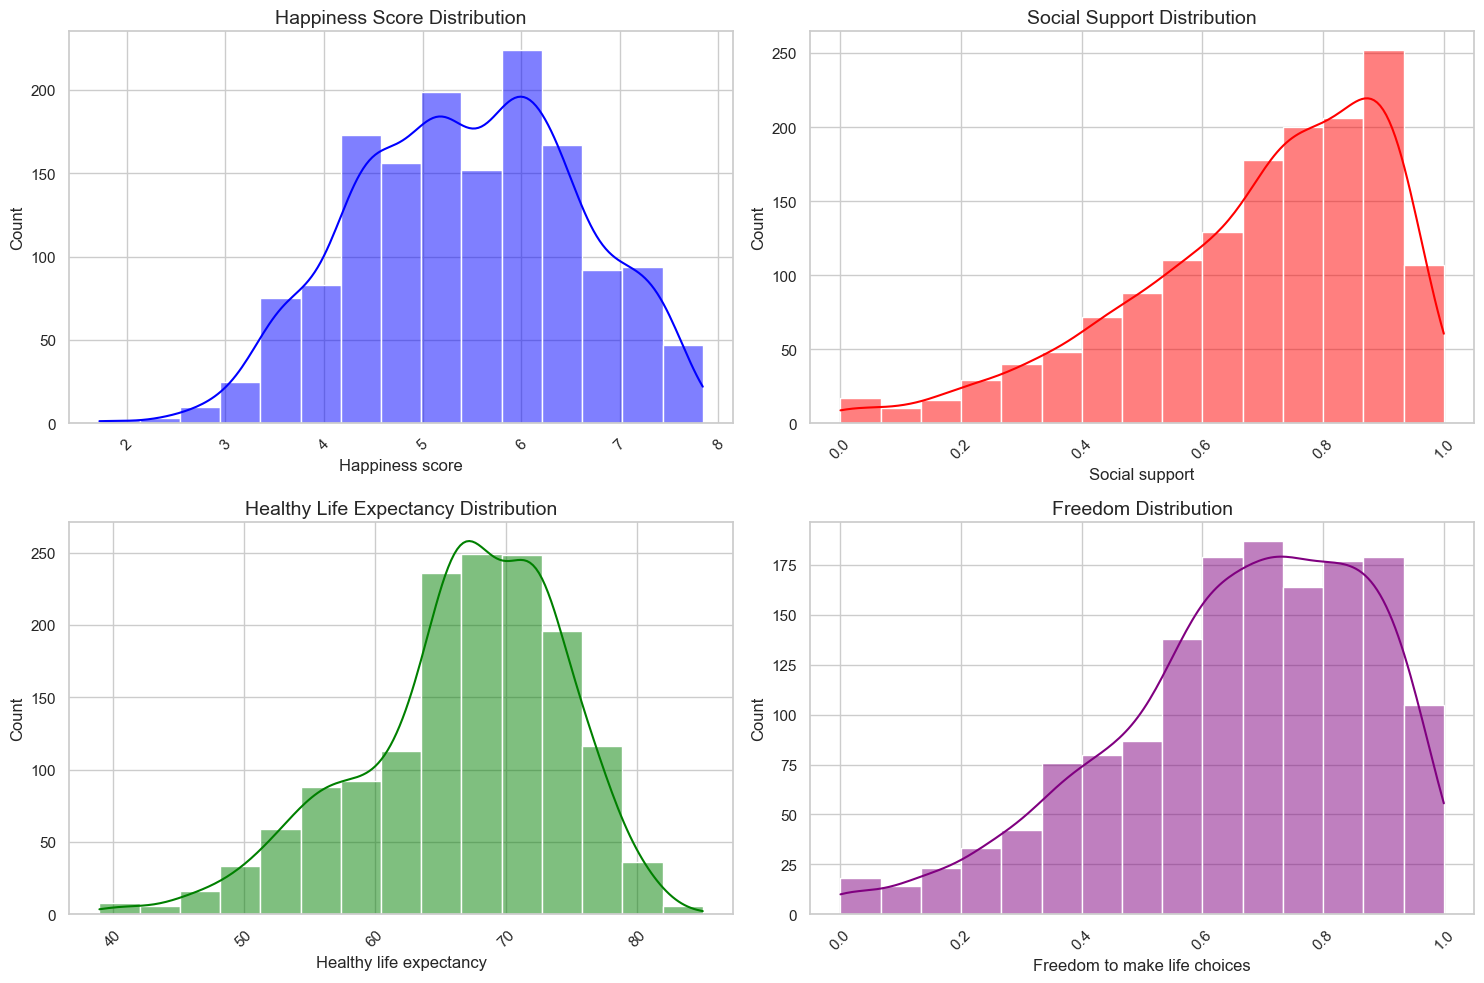

In [10]:
plt.figure(figsize=(15, 10))
# 1. Happiness Distrubition
plt.subplot(2, 2, 1)
sns.histplot(df['Happiness score'], kde=True, color='blue',bins=15)
plt.title('Happiness Score Distribution',fontsize=14)
plt.xticks(rotation=45)

# 2. Social Support Dİstribution
plt.subplot(2, 2, 2)
sns.histplot(df['Social support'], kde=True, color='red',bins=15)
plt.title('Social Support Distribution',fontsize=14)
plt.xticks(rotation=45)

# 3. Healthy Life Expectancy Distribution
plt.subplot(2, 2, 3)
sns.histplot(df['Healthy life expectancy'], kde=True, color='green',bins=15)
plt.title('Healthy Life Expectancy Distribution',fontsize=14)
plt.xticks(rotation=45)

# 4. Freedom Distribution
plt.subplot(2, 2, 4)
sns.histplot(df['Freedom to make life choices'], kde=True, color='purple',bins=15)
plt.title('Freedom Distribution',fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
corr_cols = [
    'Happiness score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

In [13]:
df[corr_cols] = (df[corr_cols].replace(',', '.', regex=True).apply(pd.to_numeric, errors='coerce'))

In [14]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [15]:
df_corr = df.dropna(subset=corr_cols)

In [16]:
df_corr[corr_cols].dtypes

Happiness score                 float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy           int64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [17]:
corr = df_corr[corr_cols].corr()
corr

,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Happiness score,1.000000,0.631353,0.744092,0.659959,0.591207,0.105558,0.071776
GDP per capita,0.631353,1.000000,0.575657,0.613080,0.296667,-0.077251,-0.092048
Social support,0.744092,0.575657,1.000000,0.545270,0.432634,0.019139,0.094344
Healthy life expectancy,0.659959,0.613080,0.545270,1.000000,0.353846,0.011184,-0.204177
Freedom to make life choices,0.591207,0.296667,0.432634,0.353846,1.000000,0.276411,0.121293
Generosity,0.105558,-0.077251,0.019139,0.011184,0.276411,1.000000,0.069459
Perceptions of corruption,0.071776,-0.092048,0.094344,-0.204177,0.121293,0.069459,1.000000


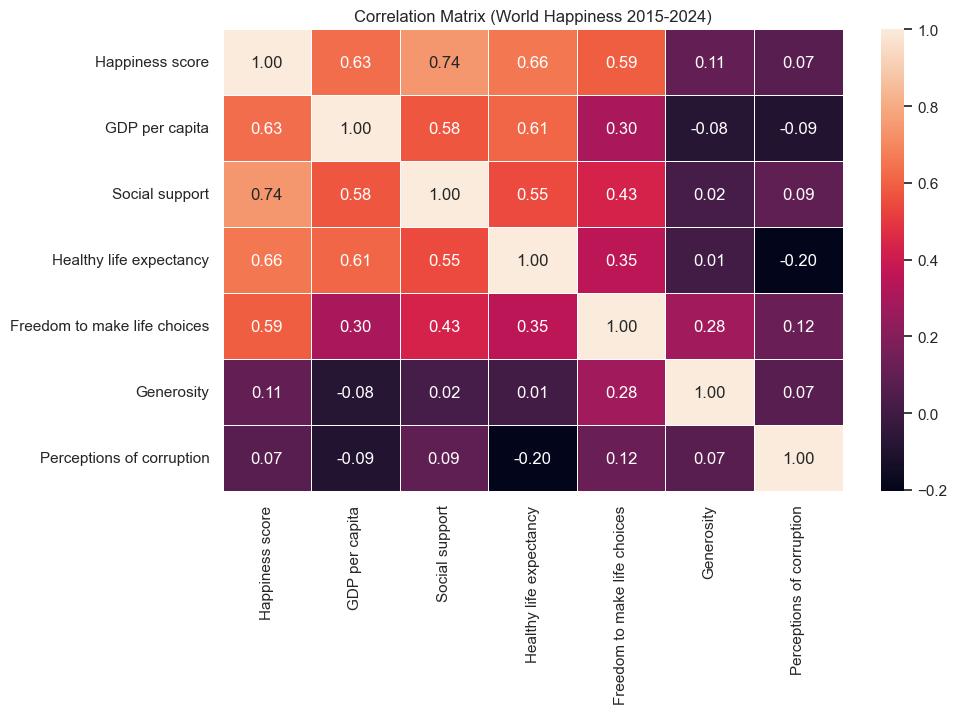

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (World Happiness 2015-2024)")
plt.show()

The most powerfull effect: 1️⃣ Social support → Happiness (0.74) 2️⃣ Healthy life expectancy → Happiness (0.66) 3️⃣ GDP per capita → Happiness (0.63) 4️⃣ Freedom → Happiness (0.59)

Lest affect:

Generosity (0.11)

Corruption perception (0.07)

### Regional Analysis

In [19]:
region_happiness = df.groupby("Regional indicator")["Happiness score"].mean().sort_values(ascending=False)

region_happiness

Regional indicator
North America and ANZ                 7.151238
Western Europe                        6.722626
Latin America and Caribbean           6.007424
Central and Eastern Europe            5.743423
East Asia                             5.691376
Southeast Asia                        5.406515
Commonwealth of Independent States    5.365825
Middle East and North Africa          5.246201
South Asia                            4.397652
Sub-Saharan Africa                    4.315985
Name: Happiness score, dtype: float64

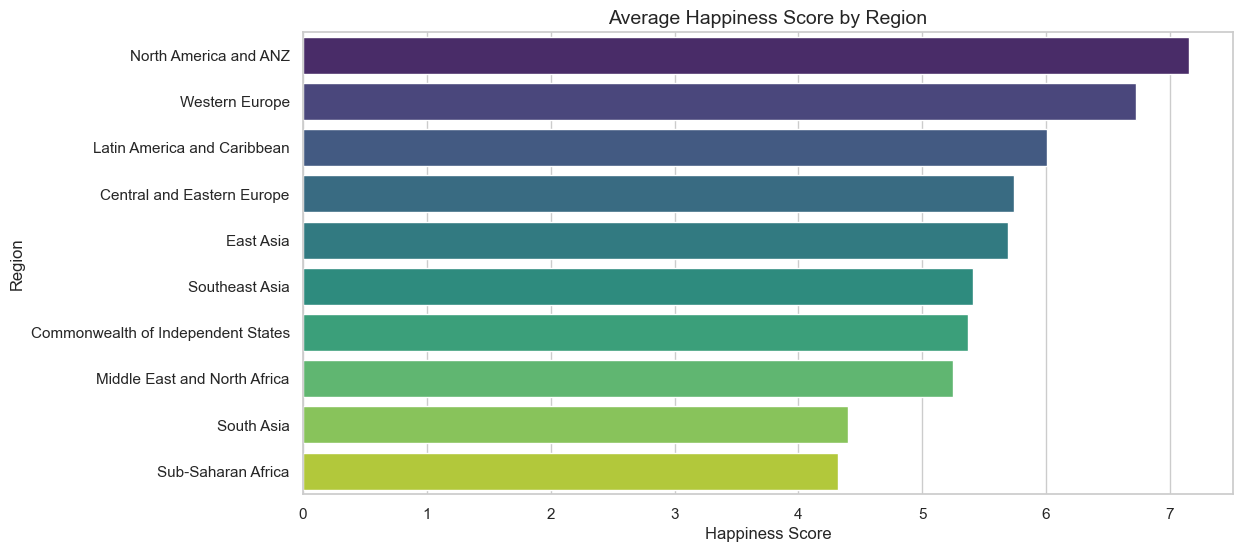

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(x=region_happiness.values,y=region_happiness.index,palette="viridis")

plt.title("Average Happiness Score by Region", fontsize=14)
plt.xlabel("Happiness Score")
plt.ylabel("Region")

plt.show()

In [21]:
region_country = df[['Regional indicator','Country','Happiness score']]

region_country.head()

,Regional indicator,Country,Happiness score
0,Western Europe,Switzerland,7.587
1,Western Europe,Iceland,7.561
2,Western Europe,Denmark,7.527
3,Western Europe,Norway,7.522
4,North America and ANZ,Canada,7.427


In [22]:
top10 = df[['Country','Regional indicator','Happiness score']] \
        .sort_values(by='Happiness score', ascending=False) \
        .head(10)
top10

,Country,Regional indicator,Happiness score
972,Finland,Western Europe,7.8421
1120,Finland,Western Europe,7.8210
780,Finland,Western Europe,7.8087
1225,Finland,Western Europe,7.8042
625,Finland,Western Europe,7.7689
1401,Finland,Western Europe,7.7407
781,Denmark,Western Europe,7.6456
1112,Denmark,Western Europe,7.6362
514,Finland,Western Europe,7.6321
965,Denmark,Western Europe,7.6195


In [23]:
bottom10 = df[['Country','Regional indicator','Happiness score']] \
           .sort_values(by='Happiness score') \
           .head(10)

bottom10

,Country,Regional indicator,Happiness score
1362,Afghanistan,South Asia,1.7210
1361,Afghanistan,South Asia,1.8590
1360,Lebanon,Middle East and North Africa,2.3922
1080,Afghanistan,South Asia,2.4038
932,Afghanistan,South Asia,2.5229
931,Afghanistan,South Asia,2.5669
469,Central African Republic,Sub-Saharan Africa,2.6930
1433,Lebanon,Middle East and North Africa,2.7065
930,South Sudan,Sub-Saharan Africa,2.8166
157,Togo,Sub-Saharan Africa,2.8390


#### Wonder about United States USA

In [24]:
df[df["Country"] == "United States"][["Year","Happiness score"]]

,Year,Happiness score
14,2015,7.1190
282,2016,7.1040
352,2017,6.9930
617,2018,6.8860
643,2019,6.8923
797,2020,6.9396
1072,2021,6.9515
1217,2022,6.9768
1239,2023,6.8937
1494,2024,6.7248


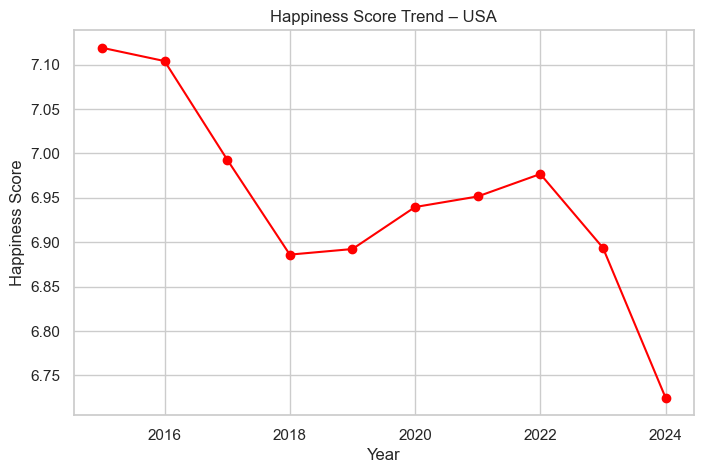

In [27]:
usa = df[df["Country"]=="United States"]

plt.figure(figsize=(8,5))

plt.plot(usa["Year"], usa["Happiness score"], marker="o", color="red")

plt.title("Happiness Score Trend – USA")
plt.xlabel("Year")
plt.ylabel("Happiness Score")

plt.show()

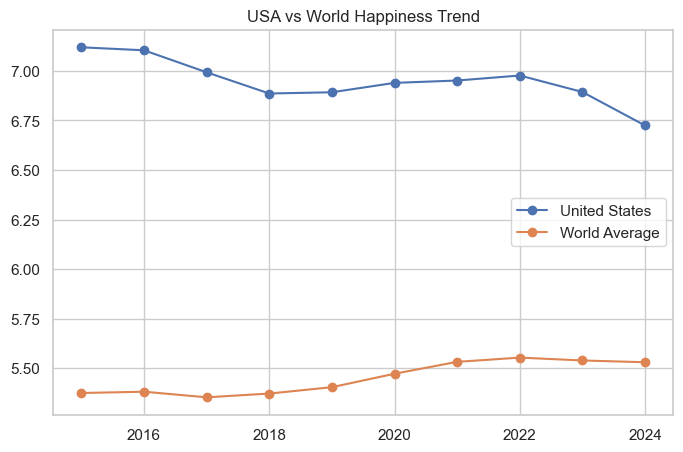

In [28]:
world_avg = df.groupby("Year")["Happiness score"].mean()

plt.figure(figsize=(8,5))

plt.plot(usa["Year"], usa["Happiness score"], marker="o", label="United States")
plt.plot(world_avg.index, world_avg.values, marker="o", label="World Average")

plt.legend()
plt.title("USA vs World Happiness Trend")

plt.show()

In [29]:
usa = df[df["Country"] == "United States"]

In [30]:
factors = [
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]

usa_factors = usa[factors].mean()
normalized = (usa_factors - usa_factors.min()) / (usa_factors.max() - usa_factors.min())

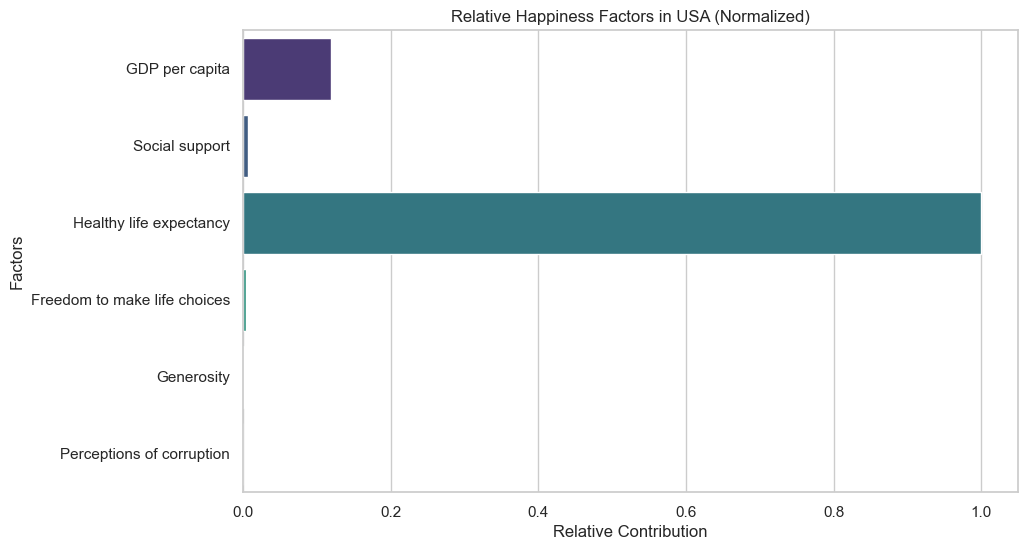

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=normalized.values,
    y=normalized.index,
    palette="viridis"
)

plt.title("Relative Happiness Factors in USA (Normalized)")
plt.xlabel("Relative Contribution")
plt.ylabel("Factors")

plt.show()

### Global Happiness Map

In [32]:
latest_year = df["Year"].max()
latest_df = df[df["Year"] == latest_year]

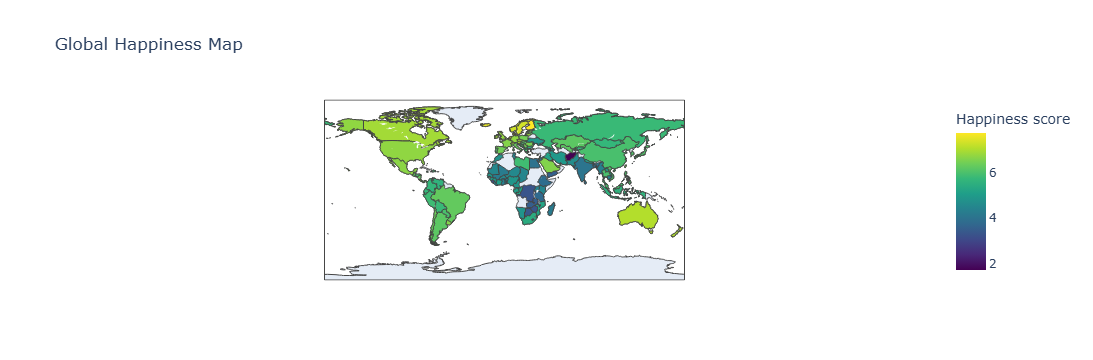

In [33]:
import plotly.express as px

fig = px.choropleth(
    latest_df,
    locations="Country",
    locationmode="country names",
    color="Happiness score",
    hover_name="Country",
    color_continuous_scale="Viridis",
    title="Global Happiness Map"
)

fig.show()


Through exploratory data analysis and visual analytics, this project uncovers the fundamental structural drivers of global well-being across a ten-year span (2015–2024). The data clearly demonstrates that social support, healthy life expectancy, and GDP per capita serve as the primary pillars of overall happiness scores. Regional visualizations highlight persistent disparities: Western Europe and North America consistently lead in well-being metrics, whereas regions navigating economic turmoil or institutional instability show marked vulnerabilities. Ultimately, tracking these longitudinal shifts illustrates how socioeconomic changes directly impact national satisfaction, reinforcing the critical role of data visualization in shaping policy and human-centric insights.

In [34]:
df.to_csv("happiness_cleaned.csv", index=False)

In [35]:
import joblib

joblib.dump(df, "happiness_dataset.joblib")

['happiness_dataset.joblib']